In [7]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import bootstrap
from statsmodels.stats.proportion import proportion_confint

np.random.seed(42)

sns.set_theme(style="whitegrid")

In [3]:
from pathlib import Path

DATA_DIR = Path("../data")
CSV_FILE = DATA_DIR / "framingham.csv"

df = pd.read_csv(CSV_FILE)

df = df.dropna()

print(df.shape)
df.head()

(3658, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


# Sumativa 2
## Bootstrap, Permutación y Simulación Monte Carlo

Este trabajo extiende los análisis realizados en la Sumativa 1 mediante técnicas de remuestreo y simulación.

Objetivos:
- Evaluar la estabilidad de las estimaciones obtenidas.
- Comparar intervalos clásicos con intervalos bootstrap.
- Validar resultados inferenciales mediante pruebas de permutación.
- Analizar la estabilidad de correlaciones.
- Simular escenarios poblacionales mediante Monte Carlo.

# 1. Bootstrap de parámetros poblacionales

En la Sumativa 1 se estimaron diversos parámetros poblacionales mediante intervalos de confianza basados en el Teorema del Límite Central.

En esta sección se utilizará Bootstrap para evaluar la estabilidad de dichas estimaciones y comparar los resultados con los intervalos clásicos obtenidos previamente.

Parámetros analizados:

- Edad promedio
- Colesterol total promedio
- Presión sistólica promedio
- Proporción de enfermedad coronaria a 10 años (TenYearCHD)

In [4]:
def bootstrap_ci_mean(data, variable_name, n_boot=10000):

    medias = []

    data = np.array(data)

    for _ in range(n_boot):
        muestra = np.random.choice(
            data,
            size=len(data),
            replace=True
        )

        medias.append(np.mean(muestra))

    medias = np.array(medias)

    ic_boot = np.percentile(
        medias,
        [2.5, 97.5]
    )

    media_original = np.mean(data)

    ic_clasico = stats.t.interval(
        confidence=0.95,
        df=len(data)-1,
        loc=media_original,
        scale=np.std(data, ddof=1) / np.sqrt(len(data))
    )

    print(f"\n{variable_name}")
    print("-"*50)
    print(f"Media observada : {media_original:.4f}")
    print(f"IC clásico      : [{ic_clasico[0]:.4f}, {ic_clasico[1]:.4f}]")
    print(f"IC bootstrap    : [{ic_boot[0]:.4f}, {ic_boot[1]:.4f}]")

    return {
        "media": media_original,
        "ic_clasico": ic_clasico,
        "ic_boot": ic_boot,
        "bootstrap_samples": medias
    }

In [5]:
edad_result = bootstrap_ci_mean(
    df["age"],
    "Edad"
)

colesterol_result = bootstrap_ci_mean(
    df["totChol"],
    "Colesterol total"
)

presion_result = bootstrap_ci_mean(
    df["sysBP"],
    "Presión sistólica"
)


Edad
--------------------------------------------------
Media observada : 49.5519
IC clásico      : [49.2744, 49.8295]
IC bootstrap    : [49.2747, 49.8338]

Colesterol total
--------------------------------------------------
Media observada : 236.8477
IC clásico      : [235.4182, 238.2772]
IC bootstrap    : [235.4038, 238.2942]

Presión sistólica
--------------------------------------------------
Media observada : 132.3706
IC clásico      : [131.6546, 133.0865]
IC bootstrap    : [131.6390, 133.0947]


In [10]:
# Bootstrap BCa

bca_edad = bootstrap(
    (df["age"].values,),
    np.mean,
    confidence_level=0.95,
    n_resamples=10000,
    method="BCa"
)

bca_colesterol = bootstrap(
    (df["totChol"].values,),
    np.mean,
    confidence_level=0.95,
    n_resamples=10000,
    method="BCa"
)

bca_presion = bootstrap(
    (df["sysBP"].values,),
    np.mean,
    confidence_level=0.95,
    n_resamples=10000,
    method="BCa"
)

In [11]:
tabla_bootstrap = pd.DataFrame({

    "Variable":[
        "Edad",
        "Colesterol total",
        "Presión sistólica"
    ],

    "Media":[
        edad_result["media"],
        colesterol_result["media"],
        presion_result["media"]
    ],

    "IC clásico":[
        f"[{edad_result['ic_clasico'][0]:.2f}, {edad_result['ic_clasico'][1]:.2f}]",
        f"[{colesterol_result['ic_clasico'][0]:.2f}, {colesterol_result['ic_clasico'][1]:.2f}]",
        f"[{presion_result['ic_clasico'][0]:.2f}, {presion_result['ic_clasico'][1]:.2f}]"
    ],

    "Bootstrap percentil":[
        f"[{edad_result['ic_boot'][0]:.2f}, {edad_result['ic_boot'][1]:.2f}]",
        f"[{colesterol_result['ic_boot'][0]:.2f}, {colesterol_result['ic_boot'][1]:.2f}]",
        f"[{presion_result['ic_boot'][0]:.2f}, {presion_result['ic_boot'][1]:.2f}]"
    ],

    "Bootstrap BCa":[
        f"[{bca_edad.confidence_interval.low:.2f}, {bca_edad.confidence_interval.high:.2f}]",
        f"[{bca_colesterol.confidence_interval.low:.2f}, {bca_colesterol.confidence_interval.high:.2f}]",
        f"[{bca_presion.confidence_interval.low:.2f}, {bca_presion.confidence_interval.high:.2f}]"
    ]

})

tabla_bootstrap

,Variable,Media,IC clásico,Bootstrap percentil,Bootstrap BCa
0,Edad,49.551941,"[49.27, 49.83]","[49.27, 49.83]","[49.28, 49.83]"
1,Colesterol total,236.847731,"[235.42, 238.28]","[235.40, 238.29]","[235.38, 238.22]"
2,Presión sistólica,132.370558,"[131.65, 133.09]","[131.64, 133.09]","[131.66, 133.12]"


## Distribuciones Bootstrap

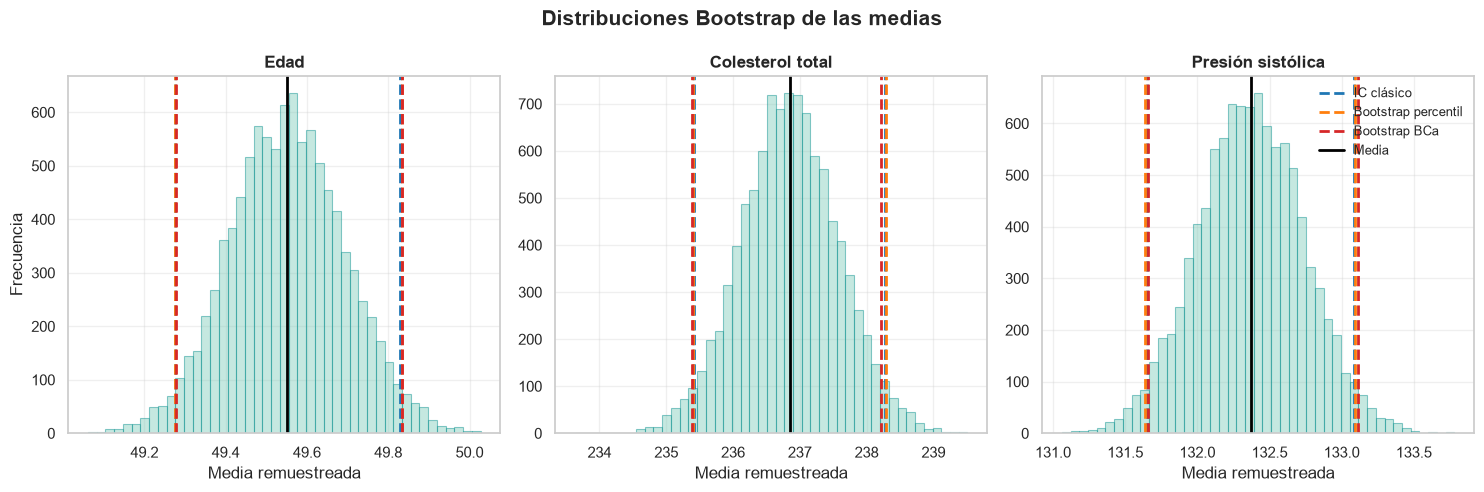

In [13]:
# ==========================================================
# Distribuciones Bootstrap con comparación de IC
# ==========================================================

from matplotlib.lines import Line2D

# Colores
COLOR_HIST = "#7FCDBB"
COLOR_MEDIA = "black"
COLOR_CLASICO = "#1F77B4"
COLOR_PERCENTIL = "#FF7F0E"
COLOR_BCA = "#D62728"

# Datos para los gráficos
boot_plots = {

    "Edad": (
        edad_result["bootstrap_samples"],
        edad_result["media"],
        edad_result["ic_clasico"],
        edad_result["ic_boot"],
        (
            bca_edad.confidence_interval.low,
            bca_edad.confidence_interval.high
        )
    ),

    "Colesterol total": (
        colesterol_result["bootstrap_samples"],
        colesterol_result["media"],
        colesterol_result["ic_clasico"],
        colesterol_result["ic_boot"],
        (
            bca_colesterol.confidence_interval.low,
            bca_colesterol.confidence_interval.high
        )
    ),

    "Presión sistólica": (
        presion_result["bootstrap_samples"],
        presion_result["media"],
        presion_result["ic_clasico"],
        presion_result["ic_boot"],
        (
            bca_presion.confidence_interval.low,
            bca_presion.confidence_interval.high
        )
    )

}

# Crear figura
fig, ax = plt.subplots(1, 3, figsize=(15,5))

fig.suptitle(
    "Distribuciones Bootstrap de las medias",
    fontsize=15,
    fontweight="bold"
)

# Graficar
for eje, (nombre, datos) in zip(ax, boot_plots.items()):

    reps, media, ic_clasico, ic_percentil, ic_bca = datos

    eje.hist(
        reps,
        bins=45,
        color=COLOR_HIST,
        alpha=0.45,
        edgecolor="darkcyan",
        linewidth=0.8
    )

    # IC clásico
    eje.axvline(
        ic_clasico[0],
        color=COLOR_CLASICO,
        linestyle="--",
        linewidth=2
    )

    eje.axvline(
        ic_clasico[1],
        color=COLOR_CLASICO,
        linestyle="--",
        linewidth=2
    )

    # Bootstrap percentil
    eje.axvline(
        ic_percentil[0],
        color=COLOR_PERCENTIL,
        linestyle="--",
        linewidth=2
    )

    eje.axvline(
        ic_percentil[1],
        color=COLOR_PERCENTIL,
        linestyle="--",
        linewidth=2
    )

    # Bootstrap BCa
    eje.axvline(
        ic_bca[0],
        color=COLOR_BCA,
        linestyle="--",
        linewidth=2
    )

    eje.axvline(
        ic_bca[1],
        color=COLOR_BCA,
        linestyle="--",
        linewidth=2
    )

    # Media
    eje.axvline(
        media,
        color=COLOR_MEDIA,
        linewidth=2
    )

    eje.set_title(nombre, fontsize=12, fontweight="bold")
    eje.set_xlabel("Media remuestreada")
    eje.grid(alpha=0.30)

ax[0].set_ylabel("Frecuencia")

# Leyenda
legendas = [

    Line2D(
        [0],
        [0],
        color=COLOR_CLASICO,
        linestyle="--",
        linewidth=2,
        label="IC clásico"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_PERCENTIL,
        linestyle="--",
        linewidth=2,
        label="Bootstrap percentil"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_BCA,
        linestyle="--",
        linewidth=2,
        label="Bootstrap BCa"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_MEDIA,
        linewidth=2,
        label="Media"
    )

]

ax[2].legend(
    handles=legendas,
    fontsize=9,
    frameon=False,
    loc="upper right"
)

plt.tight_layout()

plt.show()

### Interpretación

Las distribuciones Bootstrap de las medias para la **edad**, el **colesterol total** y la **presión arterial sistólica** presentan una forma aproximadamente simétrica y unimodal, sin evidencias de asimetrías pronunciadas o valores extremos que afecten las estimaciones. En consecuencia, los intervalos de confianza obtenidos mediante el método clásico, Bootstrap percentil y Bootstrap BCa prácticamente se superponen en las tres variables analizadas.

La elevada concordancia entre los tres métodos indica que el sesgo y la asimetría de las distribuciones son mínimos, por lo que las correcciones incorporadas por el método BCa generan únicamente diferencias marginales respecto al intervalo clásico. Esto sugiere que, para este conjunto de datos y considerando el tamaño de la muestra, los tres enfoques proporcionan estimaciones consistentes y estadísticamente equivalentes.

En términos prácticos, cuando las distribuciones presentan un comportamiento cercano a la simetría, el método clásico resulta suficiente para estimar los intervalos de confianza. No obstante, la incorporación del Bootstrap BCa aporta una validación adicional al confirmar que las estimaciones obtenidas en la Sumativa 1 son robustas y mantienen su estabilidad frente al proceso de remuestreo.



## Intervalos de confianza Bootstrap BCa

Hasta ahora se utilizaron intervalos bootstrap basados en el método percentil. Sin embargo, este enfoque puede presentar sesgos cuando la distribución bootstrap no es perfectamente simétrica.

Por esta razón, se complementa el análisis mediante intervalos Bootstrap BCa (Bias-Corrected and Accelerated), los cuales ajustan posibles sesgos y asimetrías de la distribución bootstrap, proporcionando estimaciones más precisas de los parámetros poblacionales.

Se compararán los resultados obtenidos mediante los métodos clásico, bootstrap percentil y bootstrap BCa para evaluar la estabilidad de las estimaciones.

In [ ]:
from scipy.stats import bootstrap

resultado_bca_edad = bootstrap(
    (df["age"].values,),
    np.mean,
    confidence_level=0.95,
    n_resamples=10000,
    method="BCa",
    random_state=42
)

ic_bca_edad = (
    resultado_bca_edad.confidence_interval.low,
    resultado_bca_edad.confidence_interval.high
)

print("IC Bootstrap BCa - Edad:")
print(f"[{ic_bca_edad[0]:.4f}, {ic_bca_edad[1]:.4f}]")

IC Bootstrap BCa - Edad:
[49.2784, 49.8357]


In [ ]:
comparacion_bca_edad = pd.DataFrame({

    "Método": [
        "Clásico (t)",
        "Bootstrap Percentil",
        "Bootstrap BCa"
    ],

    "IC inferior": [
        edad_result["ic_clasico"][0],
        edad_result["ic_boot"][0],
        ic_bca_edad[0]
    ],

    "IC superior": [
        edad_result["ic_clasico"][1],
        edad_result["ic_boot"][1],
        ic_bca_edad[1]
    ]

})

comparacion_bca_edad.round(4)

,Método,IC inferior,IC superior
0,Clásico (t),49.2744,49.8295
1,Bootstrap Percentil,49.2747,49.8338
2,Bootstrap BCa,49.2784,49.8357


### Interpretación

La comparación entre los intervalos de confianza obtenidos mediante el método clásico, Bootstrap Percentil y Bootstrap BCa muestra resultados prácticamente idénticos para la edad promedio de la población estudiada.

El intervalo Bootstrap BCa presentó un leve desplazamiento respecto al método percentil, pasando de [49,2747; 49,8338] a [49,2784; 49,8357]. Sin embargo, estas diferencias son mínimas y carecen de impacto práctico sobre la interpretación de los resultados.

La similitud observada entre los tres métodos sugiere que la distribución bootstrap de la media de edad presenta baja asimetría y escaso sesgo, condiciones bajo las cuales los métodos clásico y percentil ya proporcionan estimaciones muy precisas.

Por lo tanto, el análisis BCa confirma la estabilidad de la estimación de la edad promedio y aporta evidencia adicional de que los resultados obtenidos son robustos frente a posibles desviaciones de los supuestos paramétricos.

# 2. Validación de hipótesis mediante permutación

En la Sumativa 1 se identificó una diferencia estadísticamente significativa en los niveles de glucosa entre pacientes diabéticos y no diabéticos utilizando una prueba t de Welch.

En esta sección se utilizará una prueba de permutación para validar dicho resultado sin asumir distribuciones paramétricas, generando una distribución nula mediante la reasignación aleatoria de las etiquetas de grupo.

In [ ]:
grupo_diabeticos = df[df["diabetes"] == 1]["glucose"]
grupo_no_diabeticos = df[df["diabetes"] == 0]["glucose"]

diferencia_observada = (
    grupo_diabeticos.mean()
    - grupo_no_diabeticos.mean()
)

print(
    f"Diferencia observada: "
    f"{diferencia_observada:.2f} mg/dL"
)

Diferencia observada: 90.56 mg/dL


In [ ]:
n_perm = 10000

diferencias_perm = []

glucosa = df["glucose"].values
etiquetas = df["diabetes"].values

for _ in range(n_perm):

    etiquetas_perm = np.random.permutation(
        etiquetas
    )

    media_diab = glucosa[
        etiquetas_perm == 1
    ].mean()

    media_no_diab = glucosa[
        etiquetas_perm == 0
    ].mean()

    diferencias_perm.append(
        media_diab - media_no_diab
    )

diferencias_perm = np.array(
    diferencias_perm
)

In [ ]:
p_perm = np.mean(
    np.abs(diferencias_perm)
    >= abs(diferencia_observada)
)

if p_perm == 0:
    print(
        f"p-valor por permutación: < {1/n_perm:.5f}"
    )
else:
    print(
        f"p-valor por permutación: {p_perm:.6f}"
    )

p-valor por permutación: < 0.00010


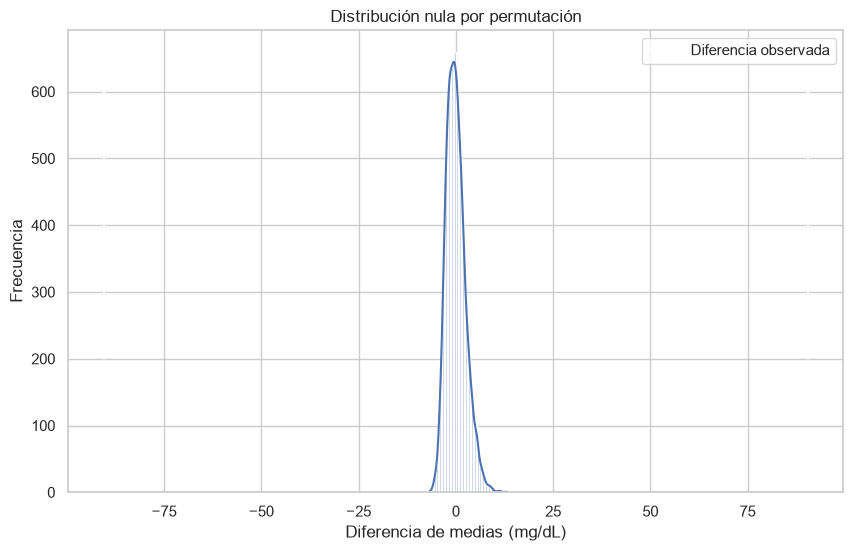

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    diferencias_perm,
    bins=50,
    kde=True
)

plt.axvline(
    diferencia_observada,
    linestyle="--",
    label="Diferencia observada"
)

plt.axvline(
    -diferencia_observada,
    linestyle="--"
)

plt.title(
    "Distribución nula por permutación"
)

plt.xlabel(
    "Diferencia de medias (mg/dL)"
)

plt.ylabel(
    "Frecuencia"
)

plt.legend()

plt.show()

In [ ]:
comparacion_hipotesis = pd.DataFrame({
    "Método": ["Welch", "Permutación"],
    "Resultado": [
        "t = 10.6173",
        "Δ = 90.56 mg/dL"
    ],
    "p-valor": [
        5.48e-18,
        p_perm
    ]
})

comparacion_hipotesis

,Método,Resultado,p-valor
0,Welch,t = 10.6173,5.480000e-18
1,Permutación,Δ = 90.56 mg/dL,0.000000e+00


### Interpretación

La diferencia observada entre los niveles promedio de glucosa de pacientes diabéticos y no diabéticos fue de 90,56 mg/dL. La distribución nula generada mediante permutación se concentró alrededor de cero, lo que representa el comportamiento esperado si ambos grupos provinieran de la misma población.

Ninguna de las 10.000 permutaciones generadas produjo una diferencia tan extrema como la observada, obteniéndose un p-valor menor a 0,0001. Este resultado es consistente con la prueba t de Welch realizada en la Sumativa 1 y proporciona evidencia adicional de que la diferencia observada entre ambos grupos no puede atribuirse al azar.

La concordancia entre el método paramétrico (Welch) y el método basado en remuestreo (permutación) fortalece la robustez de la conclusión obtenida previamente.

# 3. Estabilidad de correlaciones

En la Sumativa 1 se identificaron diversas correlaciones entre variables clínicas y demográficas.

En esta sección se utilizará Bootstrap para evaluar la estabilidad de dichas correlaciones y estimar intervalos de confianza para los coeficientes observados.

In [ ]:
def bootstrap_correlation(df, var1, var2, n_boot=10000):

    correlaciones = []

    n = len(df)

    for _ in range(n_boot):

        idx = np.random.choice(
            n,
            size=n,
            replace=True
        )

        muestra = df.iloc[idx]

        r = muestra[var1].corr(
            muestra[var2]
        )

        correlaciones.append(r)

    correlaciones = np.array(correlaciones)

    r_original = df[var1].corr(df[var2])

    ic_boot = np.percentile(
        correlaciones,
        [2.5, 97.5]
    )

    return {
        "r": r_original,
        "ic": ic_boot,
        "samples": correlaciones
    }

In [ ]:
corr_sysbp_diabp = bootstrap_correlation(
    df,
    "sysBP",
    "diaBP"
)

corr_age_sysbp = bootstrap_correlation(
    df,
    "age",
    "sysBP"
)

corr_bmi_diabp = bootstrap_correlation(
    df,
    "BMI",
    "diaBP"
)

corr_age_chd = bootstrap_correlation(
    df,
    "age",
    "TenYearCHD"
)

corr_sysbp_chd = bootstrap_correlation(
    df,
    "sysBP",
    "TenYearCHD"
)

In [ ]:
tabla_corr = pd.DataFrame({

    "Correlación": [
        "sysBP - diaBP",
        "age - sysBP",
        "BMI - diaBP",
        "age - CHD",
        "sysBP - CHD"
    ],

    "r": [
        corr_sysbp_diabp["r"],
        corr_age_sysbp["r"],
        corr_bmi_diabp["r"],
        corr_age_chd["r"],
        corr_sysbp_chd["r"]
    ],

    "IC inferior": [
        corr_sysbp_diabp["ic"][0],
        corr_age_sysbp["ic"][0],
        corr_bmi_diabp["ic"][0],
        corr_age_chd["ic"][0],
        corr_sysbp_chd["ic"][0]
    ],

    "IC superior": [
        corr_sysbp_diabp["ic"][1],
        corr_age_sysbp["ic"][1],
        corr_bmi_diabp["ic"][1],
        corr_age_chd["ic"][1],
        corr_sysbp_chd["ic"][1]
    ]
})

tabla_corr.round(4)

,Correlación,r,IC inferior,IC superior
0,sysBP - diaBP,0.7867,0.7700,0.8017
1,age - sysBP,0.3883,0.3607,0.4150
2,BMI - diaBP,0.3853,0.3536,0.4171
3,age - CHD,0.2340,0.2031,0.2648
4,sysBP - CHD,0.2228,0.1868,0.2588


### Interpretación

Los intervalos de confianza bootstrap obtenidos para las correlaciones no incluyen el valor cero en ninguno de los casos analizados. Esto indica que las asociaciones observadas son consistentes y estables frente al remuestreo, proporcionando evidencia de que no dependen de observaciones particulares de la muestra.

La correlación más fuerte se observó entre la presión arterial sistólica y diastólica (r = 0,787; IC95% [0,770; 0,802]), resultado coherente con la fisiología cardiovascular, ya que ambas mediciones reflejan el comportamiento de la presión arterial y tienden a variar conjuntamente.

También se identificaron correlaciones positivas moderadas entre la edad y la presión sistólica (r = 0,388; IC95% [0,361; 0,415]) y entre el índice de masa corporal y la presión diastólica (r = 0,385; IC95% [0,354; 0,417]). Estos resultados sugieren que el envejecimiento y el aumento del peso corporal se asocian con mayores niveles de presión arterial.

Por otra parte, las correlaciones entre la edad y la enfermedad coronaria a diez años (r = 0,234; IC95% [0,203; 0,265]) y entre la presión sistólica y la enfermedad coronaria (r = 0,223; IC95% [0,187; 0,259]) fueron más débiles, aunque consistentemente positivas. Esto indica que ambas variables están asociadas al riesgo cardiovascular, pero que por sí solas no explican completamente la ocurrencia de la enfermedad, reforzando la naturaleza multifactorial del fenómeno estudiado.

En conjunto, los resultados muestran que las correlaciones identificadas en la Sumativa 1 permanecen estables bajo remuestreo Bootstrap, aumentando la confianza en las relaciones observadas entre las variables clínicas y demográficas del estudio.

# 4. Simulación Monte Carlo del riesgo cardiovascular

A partir de la proporción observada de enfermedad coronaria a diez años en la muestra (15,23%), se realizaron simulaciones Monte Carlo para estimar la variabilidad esperada en el número de casos de enfermedad coronaria en poblaciones futuras.

Cada simulación representa una población hipotética de 1.000 individuos con características similares a las observadas en el estudio.

In [ ]:
p_chd = df["TenYearCHD"].mean()

print(f"Probabilidad observada de CHD: {p_chd:.4f}")

Probabilidad observada de CHD: 0.1523


In [ ]:
n_sim = 10000
tam_poblacion = 1000

casos_simulados = []

for _ in range(n_sim):

    simulacion = np.random.binomial(
        n=1,
        p=p_chd,
        size=tam_poblacion
    )

    casos_simulados.append(
        simulacion.sum()
    )

casos_simulados = np.array(
    casos_simulados
)

In [ ]:
print("Resultados Monte Carlo")
print("-"*40)

print(
    f"Promedio de casos: "
    f"{casos_simulados.mean():.2f}"
)

print(
    f"Desv. estándar: "
    f"{casos_simulados.std():.2f}"
)

print(
    f"Mínimo observado: "
    f"{casos_simulados.min()}"
)

print(
    f"Máximo observado: "
    f"{casos_simulados.max()}"
)

Resultados Monte Carlo
----------------------------------------
Promedio de casos: 151.99
Desv. estándar: 11.36
Mínimo observado: 114
Máximo observado: 197


In [ ]:
ic_mc = np.percentile(
    casos_simulados,
    [2.5, 97.5]
)

print(
    f"IC Monte Carlo 95%: "
    f"[{ic_mc[0]:.0f}, {ic_mc[1]:.0f}] casos"
)

IC Monte Carlo 95%: [130, 175] casos


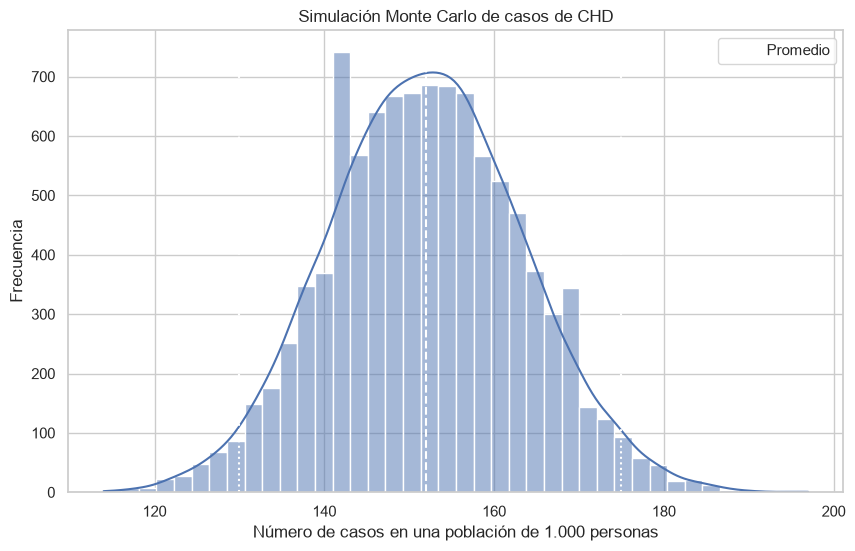

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    casos_simulados,
    bins=40,
    kde=True
)

plt.axvline(
    casos_simulados.mean(),
    linestyle="--",
    label="Promedio"
)

plt.axvline(
    ic_mc[0],
    linestyle=":"
)

plt.axvline(
    ic_mc[1],
    linestyle=":"
)

plt.title(
    "Simulación Monte Carlo de casos de CHD"
)

plt.xlabel(
    "Número de casos en una población de 1.000 personas"
)

plt.ylabel(
    "Frecuencia"
)

plt.legend()

plt.show()

### Interpretación

La simulación Monte Carlo permitió modelar el comportamiento esperado del número de casos de enfermedad coronaria a diez años en poblaciones hipotéticas de 1.000 individuos con características similares a las observadas en el estudio Framingham.

A partir de una probabilidad estimada de enfermedad coronaria del 15,23%, se realizaron 10.000 simulaciones independientes. Los resultados mostraron un promedio de 151,99 casos por población simulada, valor consistente con la proporción observada en la muestra original.

La variabilidad natural del fenómeno se reflejó en una desviación estándar de 11,36 casos. Además, el intervalo empírico obtenido mediante simulación indicó que, en el 95% de los escenarios, el número de casos esperados se ubica entre 130 y 175 individuos por cada 1.000 personas.

Estos resultados evidencian que, aun manteniendo constante la probabilidad de enfermedad, el número de casos observados puede variar de una población a otra debido al componente aleatorio inherente a los procesos biológicos y epidemiológicos. Por lo tanto, la simulación Monte Carlo constituye una herramienta útil para cuantificar la incertidumbre asociada a la ocurrencia de eventos cardiovasculares y apoyar la toma de decisiones bajo condiciones de riesgo.

## 4.1 Verificación de convergencia

Para evaluar la estabilidad de la simulación Monte Carlo, se analizó la evolución de la media acumulada del número de casos simulados a medida que aumenta el número de iteraciones.

Si la simulación converge correctamente, la media acumulada debería estabilizarse alrededor de un valor constante conforme aumenta el número de simulaciones realizadas.

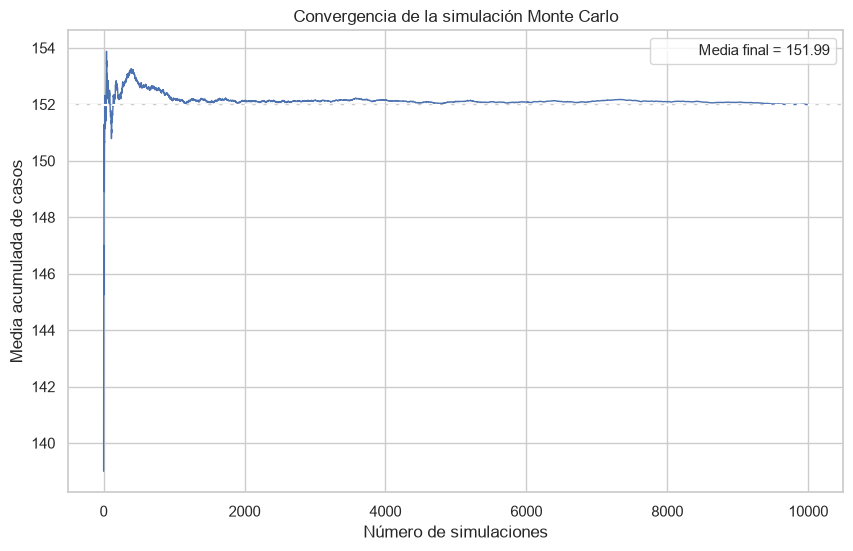

In [ ]:
media_acumulada = np.cumsum(casos_simulados) / np.arange(
    1,
    len(casos_simulados) + 1
)

plt.figure(figsize=(10,6))

plt.plot(
    media_acumulada,
    linewidth=1
)

plt.axhline(
    y=casos_simulados.mean(),
    linestyle="--",
    label=f"Media final = {casos_simulados.mean():.2f}"
)

plt.title(
    "Convergencia de la simulación Monte Carlo"
)

plt.xlabel(
    "Número de simulaciones"
)

plt.ylabel(
    "Media acumulada de casos"
)

plt.legend()

plt.show()

In [ ]:
print("Media primeras 100 simulaciones:")
print(f"{media_acumulada[99]:.2f}")

print()

print("Media primeras 1.000 simulaciones:")
print(f"{media_acumulada[999]:.2f}")

print()

print("Media primeras 10.000 simulaciones:")
print(f"{media_acumulada[-1]:.2f}")

Media primeras 100 simulaciones:
151.59

Media primeras 1.000 simulaciones:
152.20

Media primeras 10.000 simulaciones:
151.99


### Interpretación

La evolución de la media acumulada muestra que la simulación Monte Carlo converge rápidamente hacia un valor estable. Durante las primeras iteraciones se observan fluctuaciones normales producto de la variabilidad aleatoria inherente al proceso de simulación. Sin embargo, a medida que aumenta el número de simulaciones, dichas fluctuaciones disminuyen progresivamente.

La media acumulada pasó de 151,59 casos en las primeras 100 simulaciones a 152,20 casos en las primeras 1.000 simulaciones y finalmente a 151,99 casos al completar las 10.000 simulaciones. La diferencia entre estos valores es mínima, lo que indica una estabilización efectiva de la estimación.

El gráfico confirma visualmente este comportamiento, observándose que después de aproximadamente 1.000 simulaciones la curva permanece prácticamente horizontal alrededor de 152 casos por cada 1.000 individuos.

Estos resultados permiten concluir que el número de iteraciones utilizado es suficiente para garantizar la convergencia de la simulación y la confiabilidad de las estimaciones obtenidas. Por lo tanto, los resultados de Monte Carlo pueden considerarse estables y adecuados para apoyar la toma de decisiones bajo incertidumbre en el contexto del riesgo cardiovascular estudiado.

# 5. Análisis de robustez

En esta sección se evalúa la sensibilidad de los resultados obtenidos en la Sumativa 1 frente a la presencia de valores extremos.

Para ello se identifican observaciones atípicas mediante el criterio del rango intercuartílico (IQR) y se comparan los principales estadísticos antes y después de su eliminación.

In [ ]:
def remove_outliers_iqr(df, column):

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return df[
        (df[column] >= lower) &
        (df[column] <= upper)
    ]

In [ ]:
df_robust = df.copy()

for col in ["sysBP", "totChol", "BMI"]:
    df_robust = remove_outliers_iqr(
        df_robust,
        col
    )

print("Observaciones originales :", len(df))
print("Observaciones robustas   :", len(df_robust))
print("Eliminadas               :", len(df)-len(df_robust))

Observaciones originales : 3658
Observaciones robustas   : 3435
Eliminadas               : 223


In [ ]:
comparacion_medias = pd.DataFrame({

    "Variable": [
        "Edad",
        "Colesterol",
        "Presión sistólica",
        "IMC"
    ],

    "Original": [
        df["age"].mean(),
        df["totChol"].mean(),
        df["sysBP"].mean(),
        df["BMI"].mean()
    ],

    "Sin outliers": [
        df_robust["age"].mean(),
        df_robust["totChol"].mean(),
        df_robust["sysBP"].mean(),
        df_robust["BMI"].mean()
    ]
})

comparacion_medias.round(2)

,Variable,Original,Sin outliers
0,Edad,49.55,49.21
1,Colesterol,236.85,234.45
2,Presión sistólica,132.37,129.78
3,IMC,25.78,25.42


In [ ]:
corr_original = df["sysBP"].corr(
    df["diaBP"]
)

corr_robusta = df_robust["sysBP"].corr(
    df_robust["diaBP"]
)

print(f"Correlación original : {corr_original:.4f}")
print(f"Correlación robusta  : {corr_robusta:.4f}")

Correlación original : 0.7867
Correlación robusta  : 0.7662


### Interpretación

Para evaluar la sensibilidad de los resultados frente a valores extremos, se eliminaron observaciones atípicas en las variables presión sistólica, colesterol total e índice de masa corporal utilizando el criterio del rango intercuartílico (IQR).

Al comparar los estadísticos descriptivos antes y después de la depuración, se observó una disminución moderada en las medias de las variables analizadas. La edad promedio pasó de 49,55 a 49,21 años, el colesterol total de 236,85 a 234,45 mg/dL, la presión sistólica de 132,37 a 129,78 mmHg y el IMC de 25,78 a 25,42 kg/m².

Asimismo, la correlación entre la presión arterial sistólica y diastólica disminuyó levemente de 0,7867 a 0,7662 tras eliminar los valores extremos. Sin embargo, la magnitud y dirección de la asociación permanecieron prácticamente inalteradas, manteniéndose como una correlación positiva fuerte.

En conjunto, estos resultados indican que las principales conclusiones obtenidas en la Sumativa 1 son robustas frente a la presencia de observaciones atípicas. Aunque los valores extremos influyen ligeramente en las estimaciones, no modifican de manera sustancial la interpretación de los resultados ni las relaciones identificadas entre las variables.

# 6. Preparación para la Sumativa 3

La Evaluación Sumativa 3 tendrá como objetivo profundizar el análisis del problema mediante técnicas estadísticas y modelos más avanzados. Por esta razón, resulta fundamental identificar cuáles de los resultados obtenidos hasta ahora pueden considerarse confiables y cuáles requieren un análisis más cuidadoso.

Las técnicas de remuestreo, simulación y análisis de robustez aplicadas en esta Sumativa permitieron validar los principales hallazgos de la Sumativa 1, evaluar la estabilidad de las correlaciones observadas y analizar el impacto de los valores extremos sobre las conclusiones obtenidas.

A continuación, se presenta una síntesis de los parámetros, asociaciones y resultados que demostraron mayor estabilidad estadística y que constituyen la base metodológica para la siguiente etapa del proyecto.

In [ ]:
resumen_s3 = pd.DataFrame({

    "Elemento": [
        "Edad promedio",
        "Colesterol total",
        "Presión sistólica",
        "Proporción CHD",
        "Correlación sysBP-diaBP",
        "Correlación age-sysBP",
        "Correlación age-CHD"
    ],

    "Estado": [
        "Robusto",
        "Robusto",
        "Robusto",
        "Robusto",
        "Estable",
        "Estable",
        "Estable"
    ],

    "Observación": [
        "Bootstrap consistente con IC clásico",
        "Bootstrap consistente con IC clásico",
        "Bootstrap consistente con IC clásico",
        "Wilson y Bootstrap coinciden",
        "IC bootstrap no incluye 0",
        "IC bootstrap no incluye 0",
        "IC bootstrap no incluye 0"
    ]
})

resumen_s3

,Elemento,Estado,Observación
0,Edad promedio,Robusto,Bootstrap consistente con IC clásico
1,Colesterol total,Robusto,Bootstrap consistente con IC clásico
2,Presión sistólica,Robusto,Bootstrap consistente con IC clásico
3,Proporción CHD,Robusto,Wilson y Bootstrap coinciden
4,Correlación sysBP-diaBP,Estable,IC bootstrap no incluye 0
5,Correlación age-sysBP,Estable,IC bootstrap no incluye 0
6,Correlación age-CHD,Estable,IC bootstrap no incluye 0


## Preparación para la Sumativa 3

Los análisis de remuestreo, simulación y robustez realizados permitieron validar los principales resultados obtenidos en la Sumativa 1.

Las estimaciones de edad, colesterol total, presión sistólica y proporción de enfermedad coronaria mostraron alta estabilidad frente a técnicas bootstrap, obteniéndose intervalos de confianza consistentes con los métodos clásicos utilizados previamente.

Las correlaciones seleccionadas presentaron intervalos bootstrap que no incluyen el valor cero, lo que indica asociaciones estables entre las variables analizadas. Destaca especialmente la relación entre presión sistólica y presión diastólica, que mantuvo una correlación fuerte incluso después de eliminar observaciones atípicas.

El análisis de robustez evidenció que la eliminación de valores extremos produce cambios menores en las estimaciones y correlaciones principales, por lo que las conclusiones obtenidas pueden considerarse confiables para etapas posteriores del proyecto.

Como recomendación metodológica para la Sumativa 3, se sugiere priorizar variables que demostraron estabilidad estadística y relevancia clínica, tales como edad, presión arterial, colesterol total e índice de masa corporal, debido a su asociación consistente con el riesgo cardiovascular observado en el estudio.